# Wildfire Severity — EDA
Exploratory analysis on `final_dataset.csv` before modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/final_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}  |  Nulls: {df.isna().sum().sum()}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
print(f'Counties: {df["County"].nunique()}')

Rows: 2,579  |  Columns: 49  |  Nulls: 0
Date range: 2013-02-24 to 2024-12-21
Counties: 57


## 1. Dataset Overview

In [3]:
df.head(10)

,County,Date,Year,Month,Day,incident_acres_burned,log_acres_burned,ETo (in),Precip (in),Sol Rad (Ly/day),...,Max_Rel_Hum_mean_7d,Max_Rel_Hum_min_7d,Sol_Rad_mean_7d,Avg_Vap_Pres_mean_7d,ETo_sum_7d,Avg_Soil_Temp_mean_7d,Wind_Run_sum_7d,Population,Density,Land Area (mi)
0,inyo,2013-02-24,2013,2,24,407.0,6.011267,0.12,0.0,431.0,...,60.142857,56.0,386.000000,2.285714,0.83,42.285714,896.7,18351.0,1.799647,10197.0
1,san bernardino,2013-04-20,2013,4,20,30.0,3.433987,0.23,0.0,646.0,...,57.857143,31.0,648.857143,5.185714,1.59,57.514286,1534.7,2073512.0,103.324297,20068.0
2,madera,2013-04-30,2013,4,30,274.0,5.616771,0.28,0.0,650.0,...,93.571429,84.0,646.285714,11.942857,1.61,67.128571,681.0,151527.0,70.906411,2137.0
3,napa,2013-04-30,2013,4,30,75.0,4.330733,0.29,0.0,661.0,...,90.142857,75.0,613.428571,10.928571,1.50,63.228571,780.3,138538.0,184.226064,752.0
4,riverside,2013-05-01,2013,5,1,2956.0,7.991931,0.23,0.0,659.0,...,78.714286,71.0,592.428571,11.657143,1.42,65.771429,712.5,2261204.0,313.664031,7209.0
5,sonoma,2013-05-01,2013,5,1,125.0,4.836282,0.25,0.0,649.0,...,96.571429,94.0,561.571429,11.128571,1.25,60.585714,619.0,489993.0,311.106667,1575.0
6,san benito,2013-05-03,2013,5,3,354.0,5.872118,0.26,0.0,640.0,...,94.428571,88.0,603.857143,11.700000,1.51,65.128571,523.0,56599.0,40.748020,1389.0
7,riverside,2013-05-04,2013,5,4,650.0,6.478510,0.26,0.0,677.0,...,71.857143,23.0,666.714286,9.971429,1.72,66.700000,753.8,2261204.0,313.664031,7209.0
8,san bernardino,2013-05-13,2013,5,13,75.0,4.330733,0.29,0.0,675.0,...,71.857143,40.0,629.000000,8.357143,1.55,61.200000,1019.9,2073512.0,103.324297,20068.0
9,ventura,2013-05-15,2013,5,15,4346.0,8.377241,0.19,0.0,608.0,...,98.000000,95.0,600.571429,15.128571,1.34,68.071429,589.3,833516.0,452.751765,1841.0


In [4]:
df.describe().round(2)

,Date,Year,Month,Day,incident_acres_burned,log_acres_burned,ETo (in),Precip (in),Sol Rad (Ly/day),Avg Vap Pres (mBars),...,Max_Rel_Hum_mean_7d,Max_Rel_Hum_min_7d,Sol_Rad_mean_7d,Avg_Vap_Pres_mean_7d,ETo_sum_7d,Avg_Soil_Temp_mean_7d,Wind_Run_sum_7d,Population,Density,Land Area (mi)
count,2579,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,...,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00
mean,2020-02-05 20:48:29.034509,2019.54,7.29,15.50,10549.85,5.07,0.23,0.01,592.08,12.61,...,80.71,69.49,591.47,13.03,1.56,71.09,700.98,1289031.04,408.26,4337.60
min,2013-02-24 00:00:00,2013.00,1.00,1.00,2.00,1.10,0.00,0.00,0.00,0.40,...,24.86,2.00,0.00,2.29,0.00,38.46,168.00,3178.00,1.76,445.00
25%,2017-08-02 00:00:00,2017.00,6.00,8.00,32.50,3.51,0.20,0.00,514.00,9.70,...,73.29,58.00,531.21,10.53,1.31,67.26,565.80,135608.50,53.85,1496.00
50%,2019-10-09 00:00:00,2019.00,7.00,15.00,89.00,4.50,0.24,0.00,635.00,12.80,...,84.57,72.00,625.14,13.16,1.62,71.53,671.60,448287.00,132.00,3301.00
75%,2023-07-12 12:00:00,2023.00,8.00,23.00,401.00,6.00,0.28,0.00,698.00,15.50,...,90.71,84.00,686.29,15.44,1.86,75.27,803.60,2128133.00,348.27,5958.00
max,2024-12-21 00:00:00,2024.00,12.00,31.00,1032648.00,13.85,0.46,2.22,962.00,29.60,...,100.00,100.00,1583.29,25.19,2.64,93.63,1799.10,10170292.00,4023.20,20068.00
std,NaN,3.31,1.78,8.93,75074.03,2.24,0.06,0.06,142.66,4.38,...,13.57,18.04,127.50,3.62,0.40,7.29,209.36,2020594.35,667.77,4021.56


In [5]:
# Data types and null counts
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isna().sum(),
    'unique': df.nunique()
})
info

,dtype,nulls,unique
County,str,0,57
Date,datetime64[us],0,1251
Year,int64,0,12
Month,int64,0,12
Day,int64,0,31
incident_acres_burned,float64,0,821
log_acres_burned,float64,0,821
ETo (in),float64,0,45
Precip (in),float64,0,31
Sol Rad (Ly/day),float64,0,538


## 2. Target Variable — `incident_acres_burned`
The target is extremely right-skewed. We use `log1p` to normalise it for regression.

In [6]:
print('incident_acres_burned summary:')
print(df['incident_acres_burned'].describe().round(2))
print()
for p in [50, 75, 90, 95, 99]:
    print(f'  P{p:3d}: {df["incident_acres_burned"].quantile(p/100):>12,.0f} acres')

incident_acres_burned summary:
count       2579.00
mean       10549.85
std        75074.03
min            2.00
25%           32.50
50%           89.00
75%          401.00
max      1032648.00
Name: incident_acres_burned, dtype: float64

  P 50:           89 acres
  P 75:          401 acres
  P 90:        4,003 acres
  P 95:       19,609 acres
  P 99:      363,220 acres


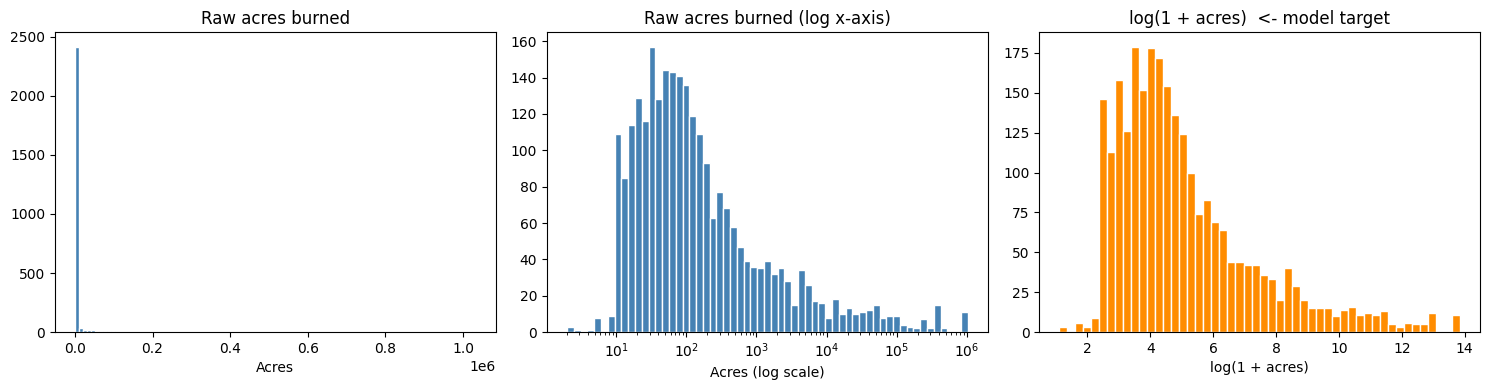

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['incident_acres_burned'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Raw acres burned')
axes[0].set_xlabel('Acres')

log_bins = np.logspace(np.log10(df['incident_acres_burned'].min()),
                       np.log10(df['incident_acres_burned'].max()), 60)
axes[1].hist(df['incident_acres_burned'], bins=log_bins, color='steelblue', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_title('Raw acres burned (log x-axis)')
axes[1].set_xlabel('Acres (log scale)')

axes[2].hist(df['log_acres_burned'], bins=50, color='darkorange', edgecolor='white')
axes[2].set_title('log(1 + acres)  <- model target')
axes[2].set_xlabel('log(1 + acres)')

plt.tight_layout()
plt.show()

In [8]:
# Fire size categories
bins   = [0, 100, 1_000, 10_000, 100_000, np.inf]
labels = ['<100 (small)', '100-1K (moderate)', '1K-10K (large)', '10K-100K (major)', '>100K (extreme)']
df['size_cat'] = pd.cut(df['incident_acres_burned'], bins=bins, labels=labels)

counts = df['size_cat'].value_counts().reindex(labels)
print('Fire count by size category:')
print(counts)
print()
print('% of fires:')
print((counts / len(df) * 100).round(1))

Fire count by size category:
size_cat
<100 (small)         1377
100-1K (moderate)     751
1K-10K (large)        286
10K-100K (major)      118
>100K (extreme)        47
Name: count, dtype: int64

% of fires:
size_cat
<100 (small)         53.4
100-1K (moderate)    29.1
1K-10K (large)       11.1
10K-100K (major)      4.6
>100K (extreme)       1.8
Name: count, dtype: float64


## 3. Temporal Patterns
When do fires happen, and are they getting worse over time?

In [9]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month').agg(
    fire_count=('incident_acres_burned', 'count'),
    total_acres=('incident_acres_burned', 'sum'),
    median_acres=('incident_acres_burned', 'median')
)
monthly.index = month_labels
monthly

,fire_count,total_acres,median_acres
Jan,12,4201.0,74.5
Feb,12,7779.0,205.5
Mar,17,2551.0,88.0
Apr,47,15450.0,75.0
May,229,132003.0,79.0
Jun,558,629997.0,85.0
Jul,666,9655451.0,90.5
Aug,433,13568221.0,100.0
Sep,287,1624224.0,100.0
Oct,213,567488.0,80.0


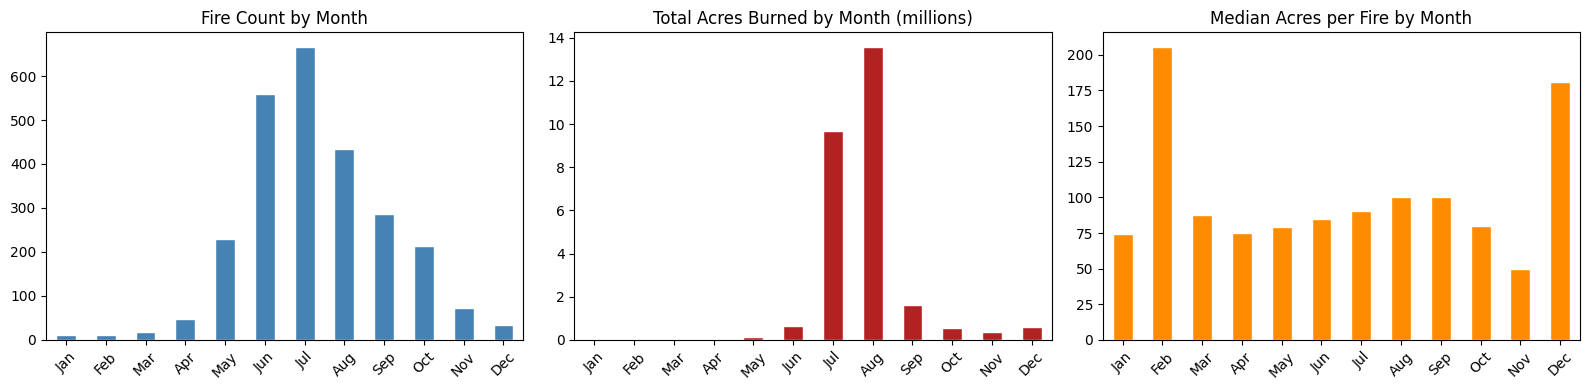

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

monthly['fire_count'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Fire Count by Month')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

(monthly['total_acres'] / 1e6).plot(kind='bar', ax=axes[1], color='firebrick', edgecolor='white')
axes[1].set_title('Total Acres Burned by Month (millions)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

monthly['median_acres'].plot(kind='bar', ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title('Median Acres per Fire by Month')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
yearly = df.groupby('Year').agg(
    fire_count=('incident_acres_burned', 'count'),
    total_acres=('incident_acres_burned', 'sum'),
    median_acres=('incident_acres_burned', 'median'),
    mean_log_acres=('log_acres_burned', 'mean')
).round(1)
yearly

,fire_count,total_acres,median_acres,mean_log_acres
Year,,,,
2013,128,462893.0,113.0,5.3
2014,66,268036.0,350.0,6.1
2015,85,425442.0,114.0,5.4
2016,144,453481.0,117.0,5.4
2017,392,1515247.0,78.0,5.0
2018,283,3216386.0,90.0,5.1
2019,241,212605.0,81.0,4.7
2020,239,12391154.0,200.0,6.1
2021,181,6064563.0,128.0,5.7


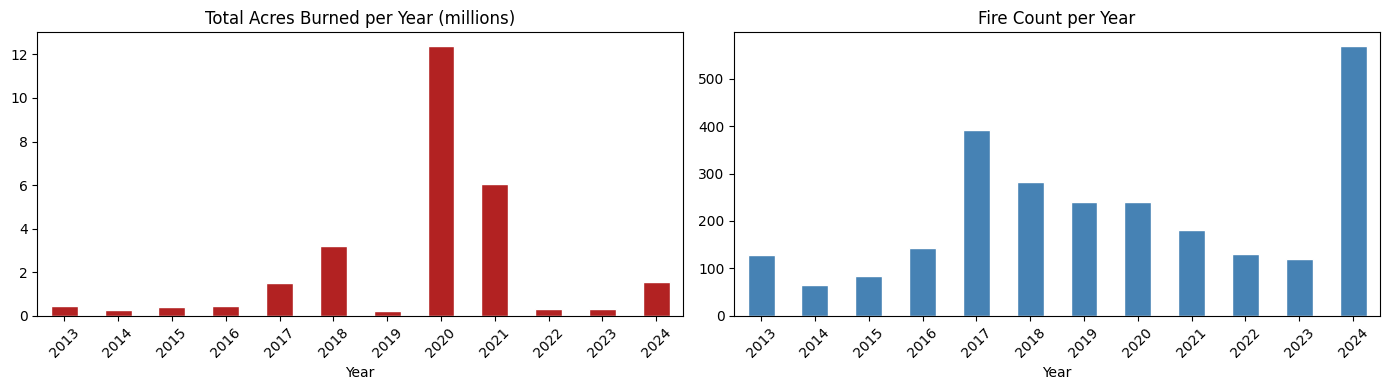

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

(yearly['total_acres'] / 1e6).plot(kind='bar', ax=axes[0], color='firebrick', edgecolor='white')
axes[0].set_title('Total Acres Burned per Year (millions)')
axes[0].tick_params(axis='x', rotation=45)

yearly['fire_count'].plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Fire Count per Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

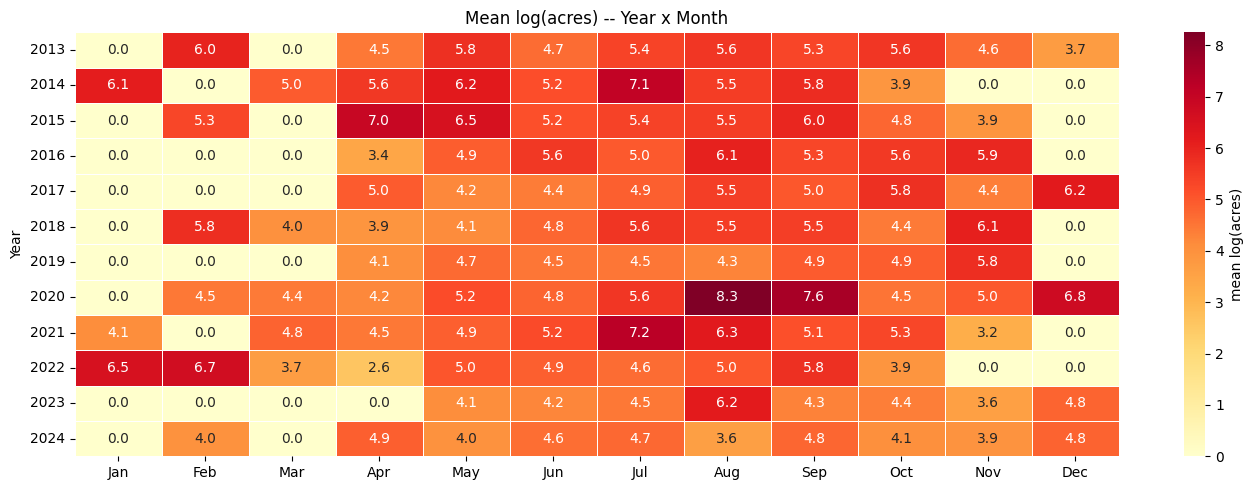

In [13]:
# Heatmap: mean log acres by Year x Month
pivot = df.groupby(['Year', 'Month'])['log_acres_burned'].mean().unstack(fill_value=0)
pivot.columns = month_labels

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.4, annot=True, fmt='.1f',
            cbar_kws={'label': 'mean log(acres)'})
plt.title('Mean log(acres) -- Year x Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## 4. Geographic Patterns

In [14]:
county_stats = df.groupby('County').agg(
    fire_count=('incident_acres_burned', 'count'),
    total_acres=('incident_acres_burned', 'sum'),
    median_acres=('incident_acres_burned', 'median'),
    mean_log_acres=('log_acres_burned', 'mean')
).round(1).sort_values('total_acres', ascending=False)

print('Top 15 counties by total acres burned:')
county_stats.head(15)

Top 15 counties by total acres burned:


,fire_count,total_acres,median_acres,mean_log_acres
County,,,,
tehama,79,2659205.0,68.0,5.1
lake,62,1981654.0,61.0,5.0
trinity,29,1931361.0,461.0,7.2
butte,93,1660863.0,80.0,4.8
shasta,94,1619793.0,75.0,5.1
mendocino,46,1535637.0,81.0,4.9
colusa,14,1515237.0,349.0,6.7
glenn,16,1466976.0,182.5,6.4
humboldt,17,1108755.0,85.0,5.7


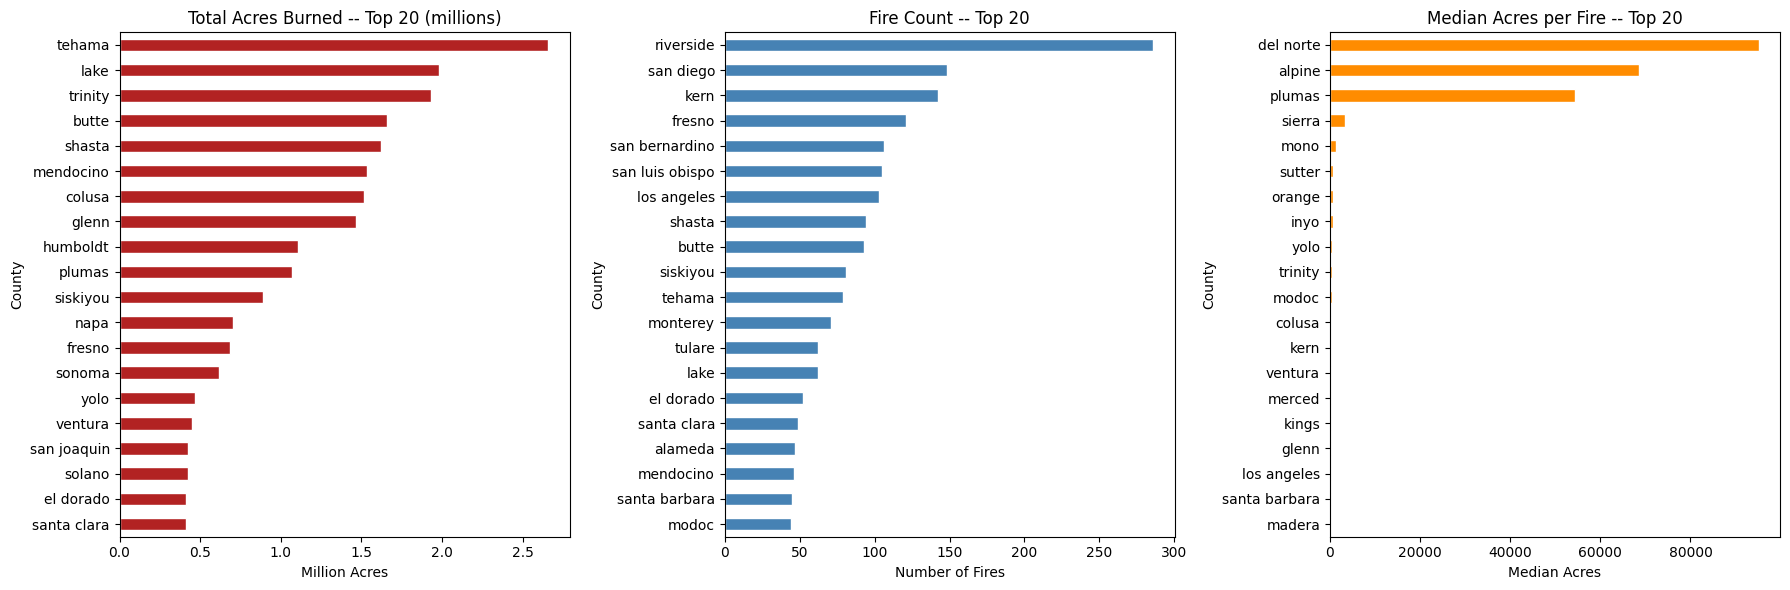

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

county_stats['total_acres'].sort_values().tail(20).div(1e6).plot(
    kind='barh', ax=axes[0], color='firebrick', edgecolor='white')
axes[0].set_title('Total Acres Burned -- Top 20 (millions)')
axes[0].set_xlabel('Million Acres')

county_stats['fire_count'].sort_values().tail(20).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Fire Count -- Top 20')
axes[1].set_xlabel('Number of Fires')

county_stats['median_acres'].sort_values().tail(20).plot(
    kind='barh', ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title('Median Acres per Fire -- Top 20')
axes[2].set_xlabel('Median Acres')

plt.tight_layout()
plt.show()

## 5. Weather Feature Distributions

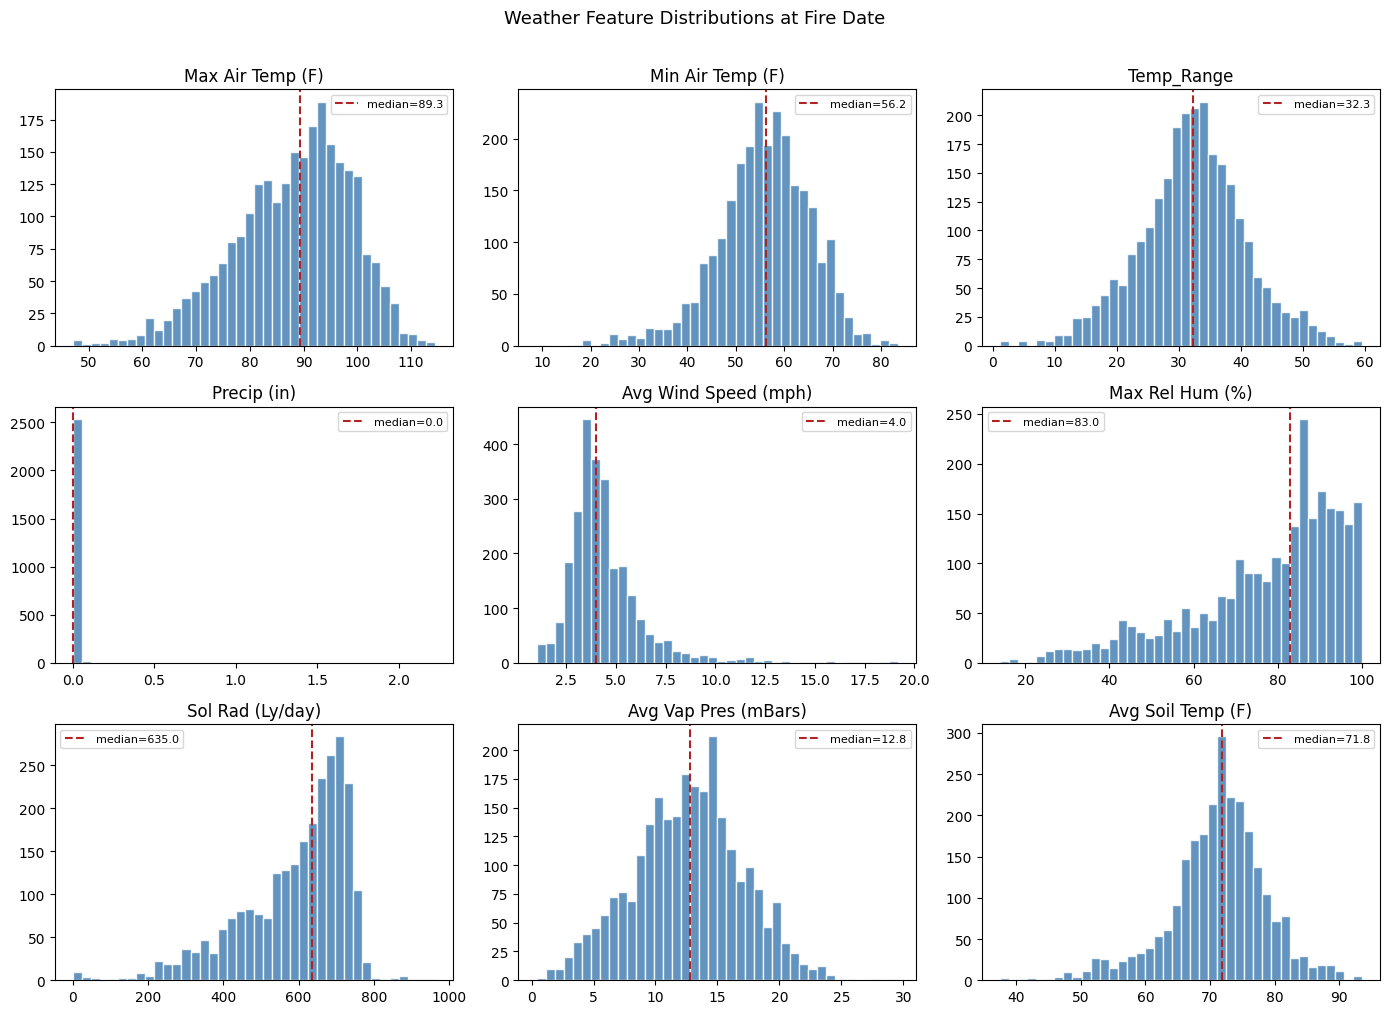

In [16]:
weather_cols = [
    'Max Air Temp (F)', 'Min Air Temp (F)', 'Temp_Range',
    'Precip (in)', 'Avg Wind Speed (mph)', 'Max Rel Hum (%)',
    'Sol Rad (Ly/day)', 'Avg Vap Pres (mBars)', 'Avg Soil Temp (F)'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(weather_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].median(), color='firebrick', linestyle='--', linewidth=1.5,
                    label=f'median={df[col].median():.1f}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Weather Feature Distributions at Fire Date', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# Weather by season
df.groupby('Season')[weather_cols].median().round(2)

,Max Air Temp (F),Min Air Temp (F),Temp_Range,Precip (in),Avg Wind Speed (mph),Max Rel Hum (%),Sol Rad (Ly/day),Avg Vap Pres (mBars),Avg Soil Temp (F)
Season,,,,,,,,,
Autumn,84.2,51.5,32.9,0.0,3.8,79.5,446.0,9.8,67.25
Spring,81.5,51.5,31.1,0.0,4.5,84.0,663.0,10.8,66.90
Summer,92.4,58.8,32.5,0.0,4.0,83.0,669.0,14.1,73.70
Winter,69.4,41.1,29.6,0.0,4.1,68.0,296.0,5.0,52.90


## 6. Rolling Window Features (7-day prior)

In [18]:
rolling_cols = [c for c in df.columns if c.endswith('_7d')]
df[rolling_cols].describe().round(2)

,Max_Air_Temp_mean_7d,Max_Air_Temp_max_7d,Min_Air_Temp_mean_7d,Min_Air_Temp_min_7d,Precip_sum_7d,Precip_max_7d,Avg_Wind_Speed_mean_7d,Avg_Wind_Speed_max_7d,Max_Rel_Hum_mean_7d,Max_Rel_Hum_min_7d,Sol_Rad_mean_7d,Avg_Vap_Pres_mean_7d,ETo_sum_7d,Avg_Soil_Temp_mean_7d,Wind_Run_sum_7d
count,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00
mean,86.26,93.12,55.03,50.36,0.04,0.02,4.17,5.48,80.71,69.49,591.47,13.03,1.56,71.09,700.98
std,9.62,9.38,8.52,9.14,0.15,0.09,1.25,2.19,13.57,18.04,127.50,3.62,0.40,7.29,209.36
min,47.81,54.10,18.47,7.90,0.00,0.00,1.00,1.00,24.86,2.00,0.00,2.29,0.00,38.46,168.00
25%,79.79,87.50,50.13,45.10,0.00,0.00,3.36,4.00,73.29,58.00,531.21,10.53,1.31,67.26,565.80
50%,87.17,94.50,55.50,51.30,0.00,0.00,4.00,5.00,84.57,72.00,625.14,13.16,1.62,71.53,671.60
75%,93.48,99.90,60.94,56.80,0.00,0.00,4.79,6.40,90.71,84.00,686.29,15.44,1.86,75.27,803.60
max,111.36,115.20,77.27,73.80,3.18,1.43,10.70,17.20,100.00,100.00,1583.29,25.19,2.64,93.63,1799.10


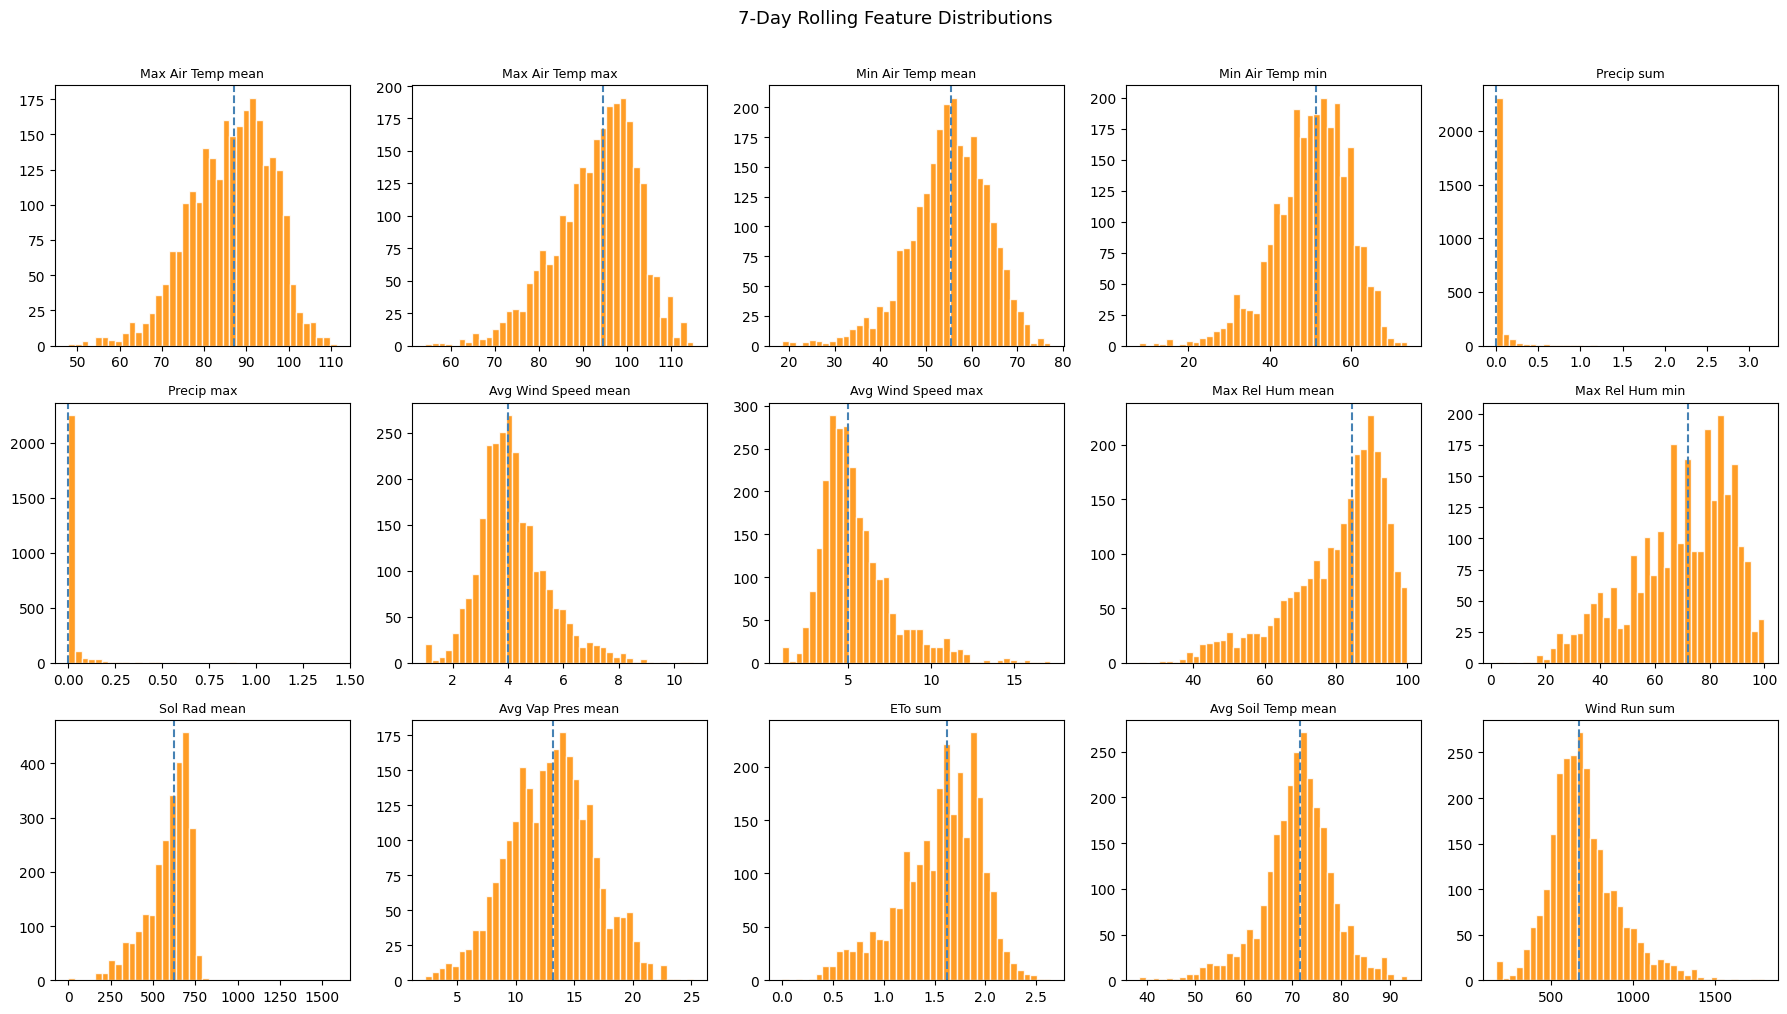

In [19]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(rolling_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='darkorange', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].median(), color='steelblue', linestyle='--', linewidth=1.5)
    axes[i].set_title(col.replace('_7d', '').replace('_', ' '), fontsize=9)

plt.suptitle('7-Day Rolling Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
zero_pct = (df['Precip_sum_7d'] == 0).mean() * 100
print(f'{zero_pct:.1f}% of fires had zero rainfall in the 7 days before ignition')
print(df['Precip_sum_7d'].describe().round(3))

78.1% of fires had zero rainfall in the 7 days before ignition
count    2579.000
mean        0.035
std         0.146
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         3.180
Name: Precip_sum_7d, dtype: float64


## 7. Drought Analysis

In [21]:
drought_cols = ['No_Drought', 'D0', 'D1', 'D2', 'D3', 'D4', 'Drought_Score', 'Any_Drought']
df[drought_cols].describe().round(2)

,No_Drought,D0,D1,D2,D3,D4,Drought_Score,Any_Drought
count,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00,2579.00
mean,45.14,54.86,39.20,29.38,15.69,6.58,145.71,54.86
std,46.25,46.25,46.65,43.63,33.82,22.17,162.46,46.25
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,26.89,73.11,1.09,0.00,0.00,0.00,86.13,73.11
75%,100.00,100.00,100.00,89.00,0.00,0.00,297.34,100.00
max,100.00,100.00,100.00,100.00,100.00,100.00,500.00,100.00


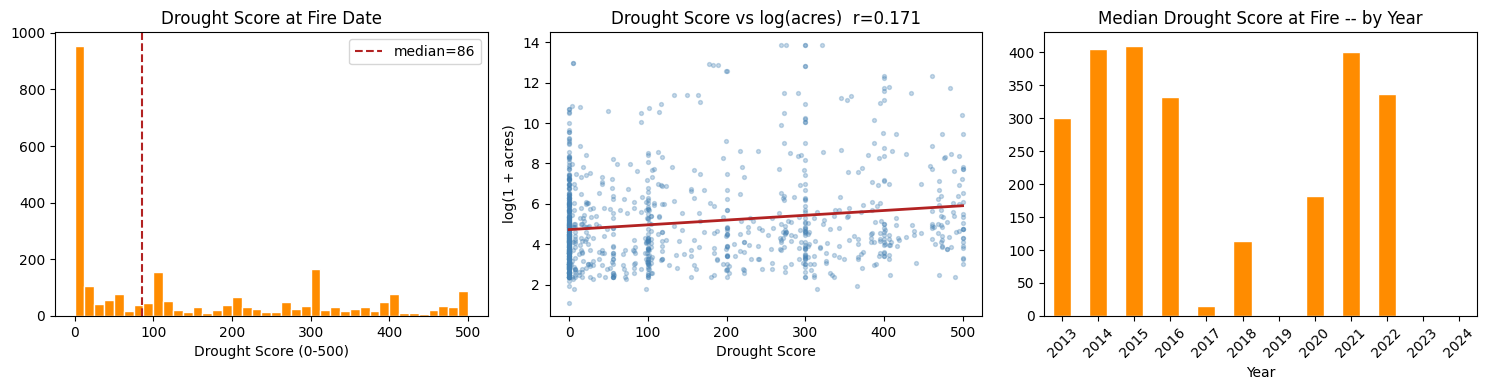

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Drought_Score'], bins=40, color='darkorange', edgecolor='white')
axes[0].axvline(df['Drought_Score'].median(), color='firebrick', linestyle='--',
                label=f'median={df["Drought_Score"].median():.0f}')
axes[0].set_title('Drought Score at Fire Date')
axes[0].set_xlabel('Drought Score (0-500)')
axes[0].legend()

sample = df.sample(1000, random_state=42)
axes[1].scatter(sample['Drought_Score'], sample['log_acres_burned'],
               alpha=0.3, s=8, color='steelblue')
m, b, r, p, _ = stats.linregress(df['Drought_Score'], df['log_acres_burned'])
xs = np.linspace(df['Drought_Score'].min(), df['Drought_Score'].max(), 100)
axes[1].plot(xs, m*xs+b, color='firebrick', linewidth=2)
axes[1].set_title(f'Drought Score vs log(acres)  r={r:.3f}')
axes[1].set_xlabel('Drought Score')
axes[1].set_ylabel('log(1 + acres)')

yr_drought = df.groupby('Year')['Drought_Score'].median()
yr_drought.plot(kind='bar', ax=axes[2], color='darkorange', edgecolor='white')
axes[2].set_title('Median Drought Score at Fire -- by Year')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
bins   = [-1, 0, 100, 200, 300, 400, 500]
labels = ['No Drought', 'D0 Abnormal', 'D1 Moderate', 'D2 Severe', 'D3 Extreme', 'D4 Exceptional']
df['drought_cat'] = pd.cut(df['Drought_Score'], bins=bins, labels=labels)

d_counts = df['drought_cat'].value_counts().reindex(labels)
print('Fires by drought category:')
print(d_counts)
print()
print('% of fires:')
print((d_counts / len(df) * 100).round(1))

Fires by drought category:
drought_cat
No Drought        848
D0 Abnormal       566
D1 Moderate       313
D2 Severe         335
D3 Extreme        274
D4 Exceptional    243
Name: count, dtype: int64

% of fires:
drought_cat
No Drought        32.9
D0 Abnormal       21.9
D1 Moderate       12.1
D2 Severe         13.0
D3 Extreme        10.6
D4 Exceptional     9.4
Name: count, dtype: float64


## 8. Feature Correlations with Target

In [24]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude  = ['incident_acres_burned', 'Year', 'Month', 'Day', 'Is_Fire_Season']
feat_cols = [c for c in num_cols if c not in exclude + ['log_acres_burned']]

corr_target = df[feat_cols + ['log_acres_burned']].corr()['log_acres_burned'] \
                .drop('log_acres_burned').sort_values(key=abs, ascending=False)

print('Features ranked by |r| with log_acres_burned:')
pd.DataFrame({'r': corr_target.round(4)})

Features ranked by |r| with log_acres_burned:


,r
Fire_Impact_Per_Capita,0.2796
D1,0.1715
Drought_Score,0.1711
No_Drought,-0.1445
Any_Drought,0.1445
D0,0.1445
D2,0.1444
Max_Air_Temp_max_7d,0.1419
Max_Air_Temp_mean_7d,0.1372
D3,0.1346


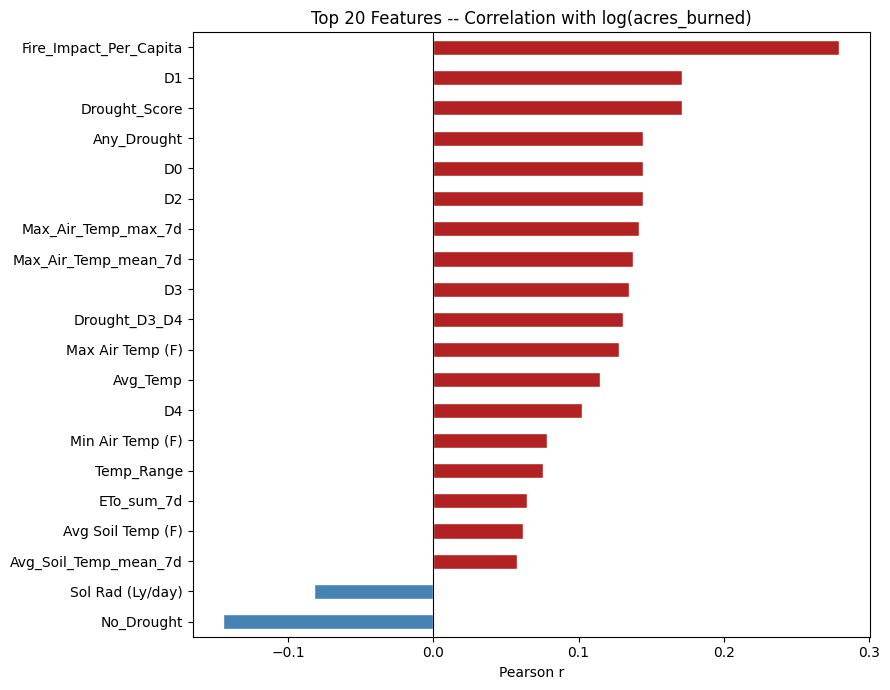

In [25]:
top20 = corr_target.head(20).sort_values()

plt.figure(figsize=(9, 7))
colors = ['firebrick' if v > 0 else 'steelblue' for v in top20.values]
top20.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features -- Correlation with log(acres_burned)')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()

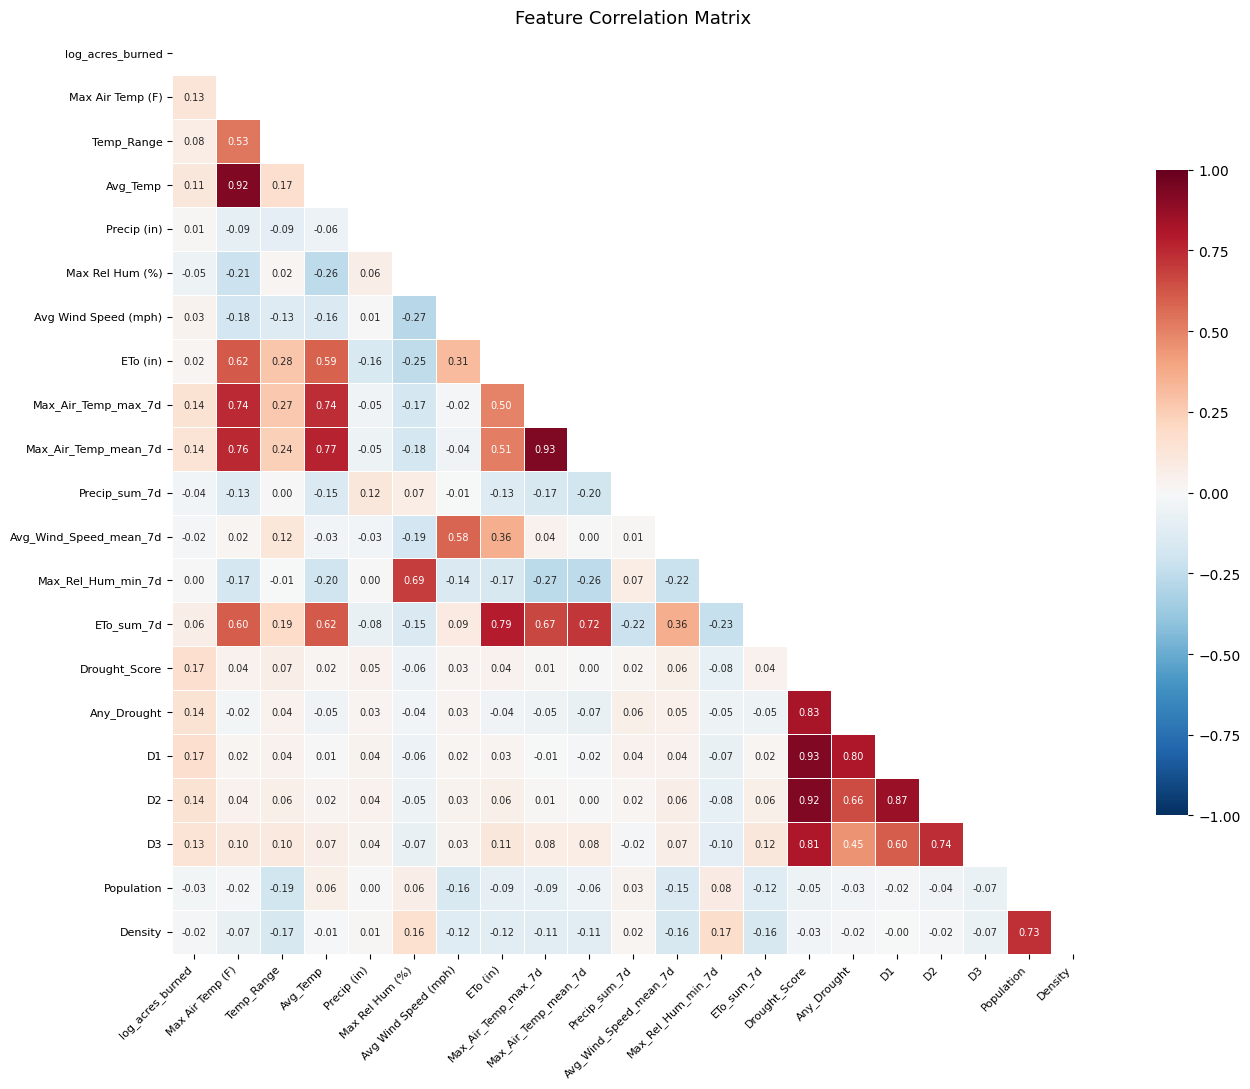

In [26]:
model_features = [
    'log_acres_burned',
    'Max Air Temp (F)', 'Temp_Range', 'Avg_Temp', 'Precip (in)',
    'Max Rel Hum (%)', 'Avg Wind Speed (mph)', 'ETo (in)',
    'Max_Air_Temp_max_7d', 'Max_Air_Temp_mean_7d',
    'Precip_sum_7d', 'Avg_Wind_Speed_mean_7d',
    'Max_Rel_Hum_min_7d', 'ETo_sum_7d',
    'Drought_Score', 'Any_Drought', 'D1', 'D2', 'D3',
    'Population', 'Density',
]

corr_mat = df[model_features].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr_mat, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot=True, fmt='.2f',
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Matrix', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Key Feature Scatter Plots

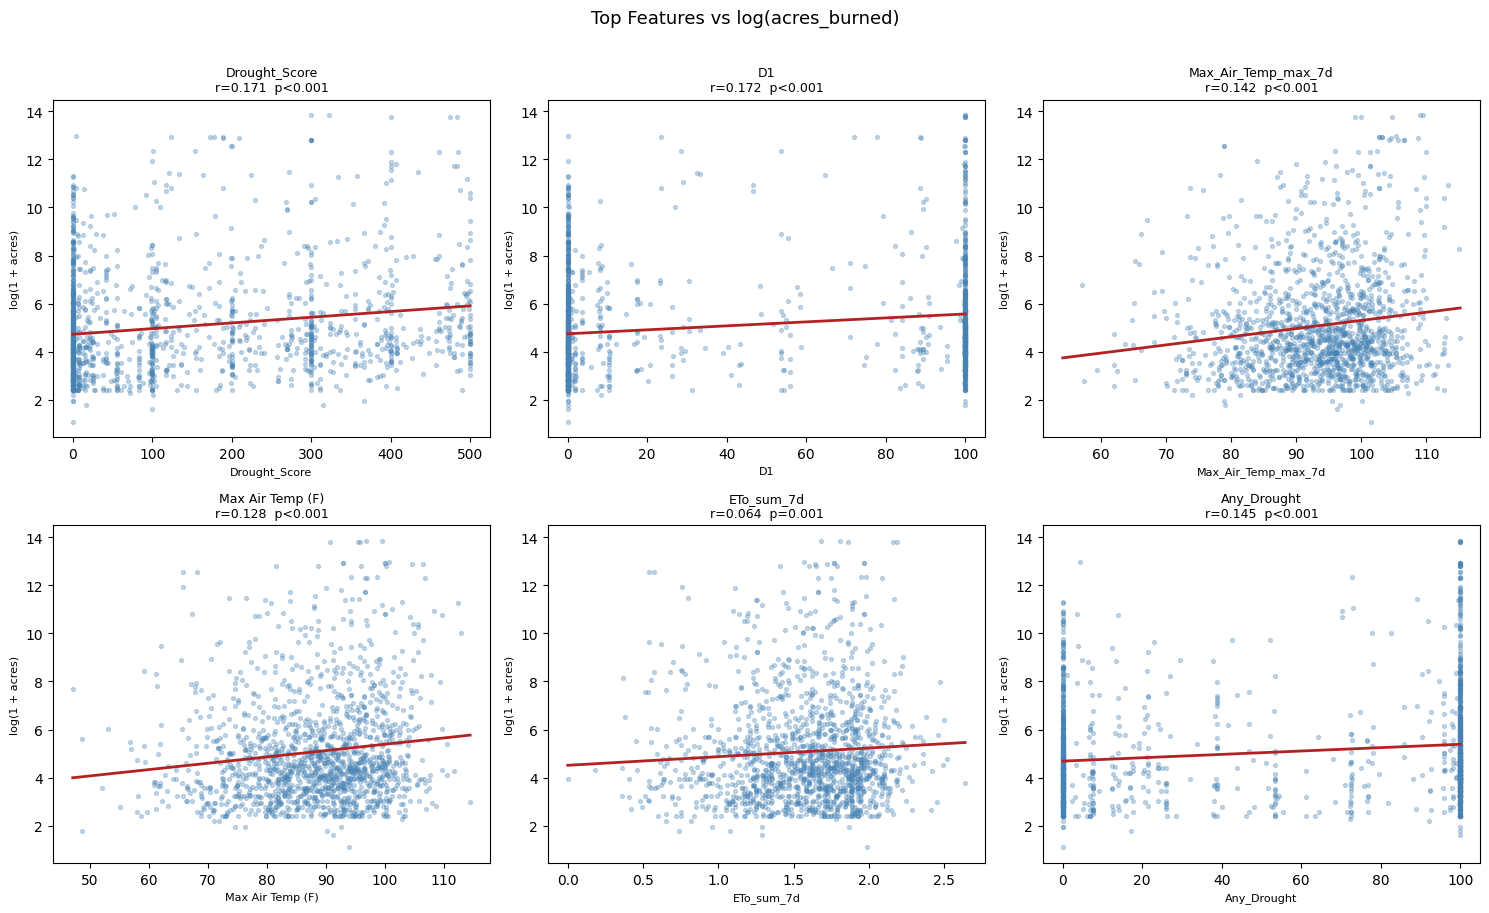

In [27]:
top_features = [
    'Drought_Score', 'D1', 'Max_Air_Temp_max_7d',
    'Max Air Temp (F)', 'ETo_sum_7d', 'Any_Drought'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
sample = df.sample(min(1500, len(df)), random_state=1)

for i, feat in enumerate(top_features):
    axes[i].scatter(sample[feat], sample['log_acres_burned'],
                   alpha=0.3, s=8, color='steelblue')
    m, b, r, p, _ = stats.linregress(df[feat], df['log_acres_burned'])
    xs = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(xs, m*xs+b, color='firebrick', linewidth=2)
    pstr = 'p<0.001' if p < 0.001 else f'p={p:.3f}'
    axes[i].set_title(f'{feat}\nr={r:.3f}  {pstr}', fontsize=9)
    axes[i].set_xlabel(feat, fontsize=8)
    axes[i].set_ylabel('log(1 + acres)', fontsize=8)

plt.suptitle('Top Features vs log(acres_burned)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Train / Test Split Preview

In [28]:
train = df[df['Year'] <= 2021]
test  = df[df['Year'] >= 2022]

print(f'Train (2013-2021): {len(train):,} rows  ({len(train)/len(df)*100:.0f}%)')
print(f'Test  (2022-2024): {len(test):,} rows  ({len(test)/len(df)*100:.0f}%)')
print()
print('Train target:')
print(train['log_acres_burned'].describe().round(3))
print()
print('Test target:')
print(test['log_acres_burned'].describe().round(3))

Train (2013-2021): 1,759 rows  (68%)
Test  (2022-2024): 820 rows  (32%)

Train target:
count    1759.000
mean        5.320
std         2.323
min         1.099
25%         3.714
50%         4.710
75%         6.252
max        13.848
Name: log_acres_burned, dtype: float64

Test target:
count    820.000
mean       4.543
std        1.959
min        1.099
25%        3.124
50%        4.069
75%        5.436
max       12.971
Name: log_acres_burned, dtype: float64
